In [28]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge,Lasso,ElasticNet,LinearRegression
from sklearn.metrics import r2_score

In [29]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

In [30]:
X.shape

(20640, 8)

In [31]:
y.shape

(20640,)

In [32]:
X = X.iloc[:].values

In [33]:
y = y.iloc[:].values

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [35]:
model_lin = LinearRegression()
model_rid = Ridge(alpha=0.1)
model_las = Lasso(alpha=0.5)
model_elas = ElasticNet(alpha=0.01)

In [36]:
model_lin.fit(X_train,y_train)
y_pred_lin =  model_lin.predict(X_test)
r2_score(y_test,y_pred_lin)

0.5757877060324526

In [37]:
model_rid.fit(X_train,y_train)
y_pred_rid =  model_rid.predict(X_test)
r2_score(y_test,y_pred_rid)

0.5757944553633947

In [38]:
model_las.fit(X_train,y_train)
y_pred_las =  model_las.predict(X_test)
r2_score(y_test,y_pred_las)

0.44572168363924836

In [39]:
model_elas.fit(X_train,y_train)
y_pred_elas =  model_elas.predict(X_test)
r2_score(y_test,y_pred_elas)

0.583586303522517

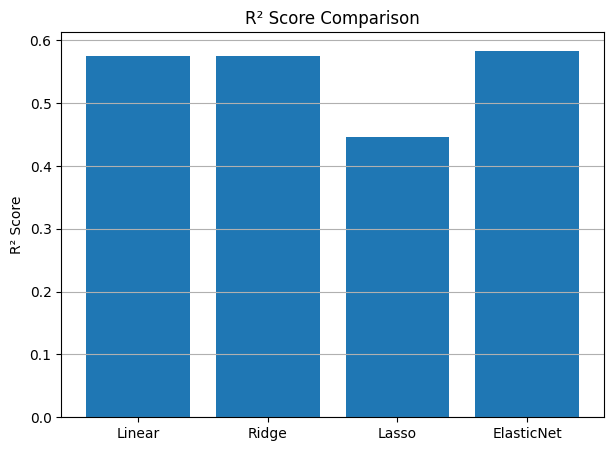

In [40]:
models = ["Linear", "Ridge", "Lasso", "ElasticNet"]
scores = [
    r2_score(y_test, y_pred_lin),
    r2_score(y_test, y_pred_rid),
    r2_score(y_test, y_pred_las),
    r2_score(y_test, y_pred_elas)
]

plt.figure(figsize=(7,5))
plt.bar(models, scores)
plt.ylabel("R² Score")
plt.title("R² Score Comparison")
plt.grid(axis='y')
plt.show()

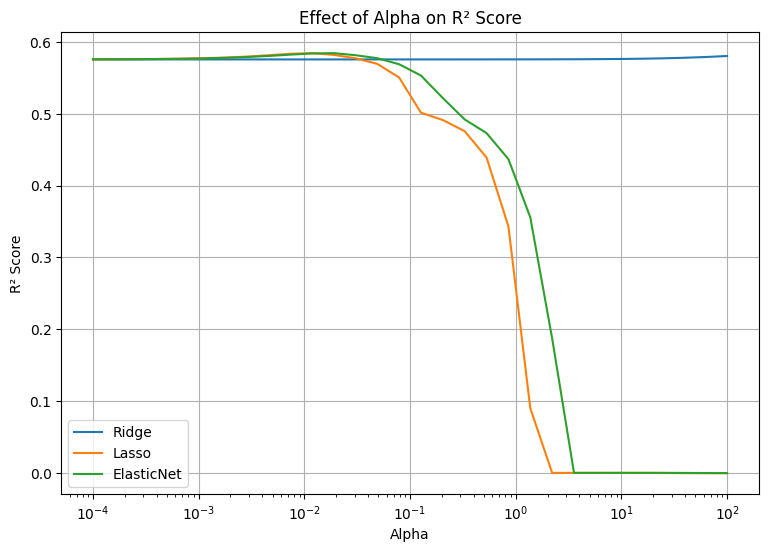

In [41]:
alphas = np.logspace(-4,2,30)

ridge_scores=[]
lasso_scores=[]
elastic_scores=[]

for alpha in alphas:

    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train,y_train)
    ridge_scores.append(r2_score(y_test,ridge.predict(X_test)))

    lasso = Lasso(alpha=alpha,max_iter=10000)
    lasso.fit(X_train,y_train)
    lasso_scores.append(r2_score(y_test,lasso.predict(X_test)))

    elastic = ElasticNet(alpha=alpha,max_iter=10000)
    elastic.fit(X_train,y_train)
    elastic_scores.append(r2_score(y_test,elastic.predict(X_test)))

plt.figure(figsize=(9,6))
plt.semilogx(alphas,ridge_scores,label="Ridge")
plt.semilogx(alphas,lasso_scores,label="Lasso")
plt.semilogx(alphas,elastic_scores,label="ElasticNet")

plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Effect of Alpha on R² Score")
plt.legend()
plt.grid(True)
plt.show()

#### Conclusion:
##### As α increases, regularization becomes stronger. A moderate α often gives the best performance, while a very large α causes underfitting and reduces the R² score.

In [42]:
alphas=np.logspace(-4,2,100)

ridge_coef=[]
lasso_coef=[]
elastic_coef=[]

for alpha in alphas:

    ridge=Ridge(alpha=alpha)
    ridge.fit(X_train,y_train)
    ridge_coef.append(ridge.coef_)

    lasso=Lasso(alpha=alpha,max_iter=10000)
    lasso.fit(X_train,y_train)
    lasso_coef.append(lasso.coef_)

    elastic=ElasticNet(alpha=alpha,max_iter=10000)
    elastic.fit(X_train,y_train)
    elastic_coef.append(elastic.coef_)

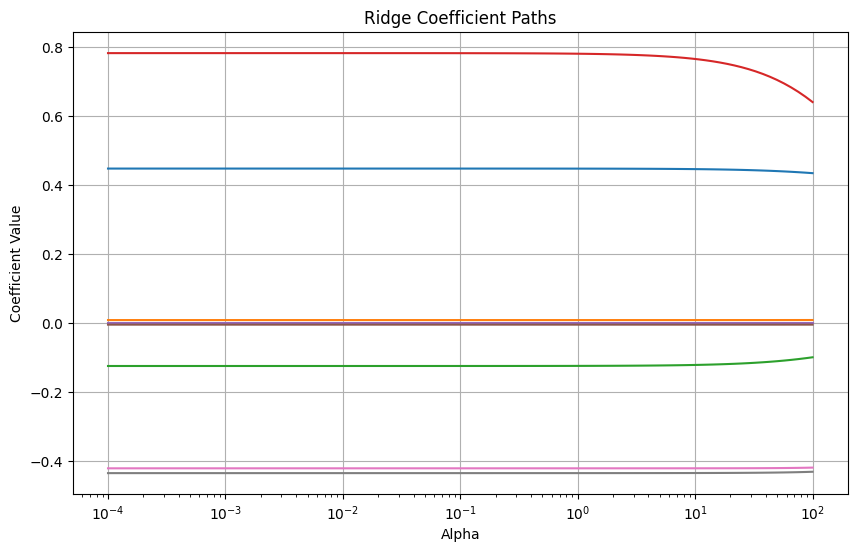

In [43]:
ridge_coef=np.array(ridge_coef)

plt.figure(figsize=(10,6))

for i in range(ridge_coef.shape[1]):
    plt.semilogx(alphas,ridge_coef[:,i])

plt.title("Ridge Coefficient Paths")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.grid(True)
plt.show()

#### Conclusion:
##### Increasing α gradually shrinks all coefficients toward zero, but none become exactly zero. Ridge reduces model complexity while retaining all features.

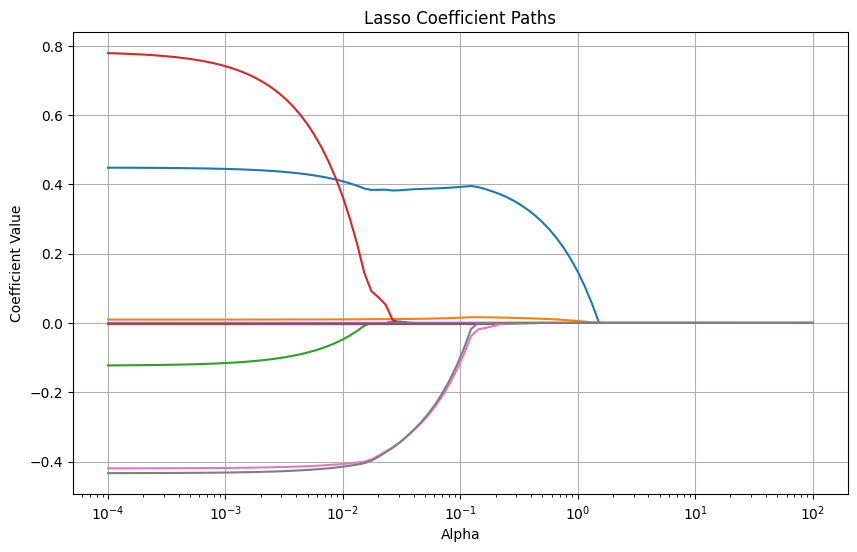

In [44]:
lasso_coef=np.array(lasso_coef)

plt.figure(figsize=(10,6))

for i in range(lasso_coef.shape[1]):
    plt.semilogx(alphas,lasso_coef[:,i])

plt.title("Lasso Coefficient Paths")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.grid(True)
plt.show()

#### Conclusion:
##### As α increases, several coefficients become exactly zero, showing that Lasso automatically performs feature selection.

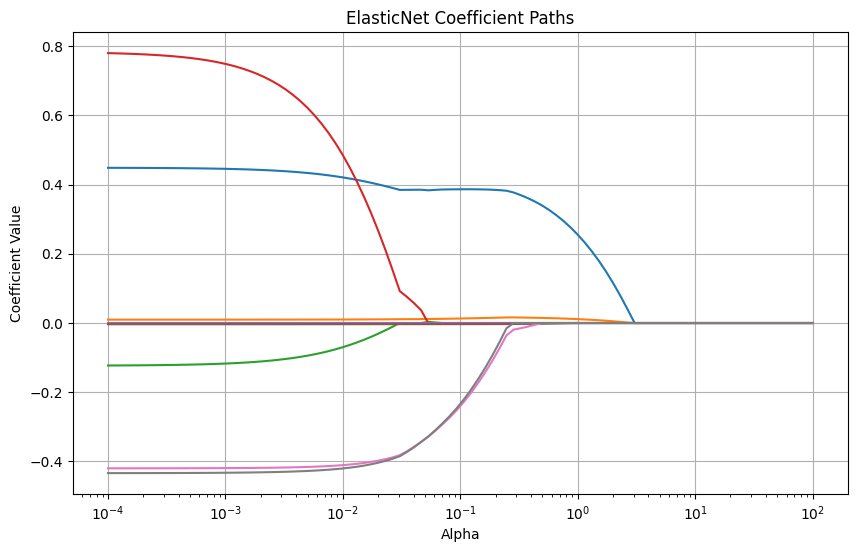

In [46]:
elastic_coef=np.array(elastic_coef)

plt.figure(figsize=(10,6))

for i in range(elastic_coef.shape[1]):
    plt.semilogx(alphas,elastic_coef[:,i])

plt.title("ElasticNet Coefficient Paths")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.grid(True)
plt.show()

#### Conclusion:
##### Elastic Net combines the behavior of Ridge and Lasso by shrinking coefficients while simultaneously eliminating less important features.